# Experiment 1 — statistical analysis (LGD)

How do the learners compare on **LGD** (metric: **R2**), across datasets, in a statistically defensible way? We follow the standard cross-dataset comparison framework (Demšar, 2006) and its successors, read as a story:

1. **PAMA** — who wins most often (descriptive).
2. **Omnibus tests** — do the methods differ *at all*?
3. **Critical-difference diagram** — which groups are indistinguishable.
4. **Win/Loss matrix** — the direction of every head-to-head.
5. **Significant pairs** — Wilcoxon *and* t-test, both Holm-corrected.
6. **Adjusted-p-value matrix** — the same, as a colour map.
7. **Bayesian ROPE analysis** — the *practical* probability of superiority.

All results here use the **HPO** runs (the tuned configuration of each method). Logic lives in `src/utils/statistical_testing.py`; this notebook narrates and calls it.

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.paths import results_root
from src.visualizations.experiment_plots import apply_style, reset_figure_dir, load_summary
from src.methods.method_config import FOUNDATION_METHODS
from src.utils import statistical_testing as st
apply_style()

RESULTS_ROOT = results_root()
SUMMARY_DIR  = RESULTS_ROOT / 'summaries'
FIGURES_DIR  = reset_figure_dir(PROJECT_ROOT / 'figures' / 'experiment1' / 'lgd_stats')
FND = sorted(FOUNDATION_METHODS)
print('results:', RESULTS_ROOT, '| figures:', FIGURES_DIR)

results: C:\Users\U0152019\PhD Documents\Projects\1. TabPFN\TabPFNCredit\results | figures: C:\Users\U0152019\PhD Documents\Projects\1. TabPFN\TabPFNCredit\figures\experiment1\lgd_stats


In [2]:
df       = load_summary(SUMMARY_DIR, experiment='experiment1', task='lgd', hpo_mode='HPO')
df_folds = load_summary(SUMMARY_DIR, experiment='experiment1', task='lgd', aggregated=False, hpo_mode='HPO')
mat  = st.metric_matrix(df, 'R2')
ranks = st.average_ranks(mat)              # best-first ordering reused everywhere
print(f'LGD: {mat.shape[1]} methods x {mat.shape[0]} datasets')

LGD: 27 methods x 7 datasets


## 1. PAMA — how often is each learner the single best?

**What it is.** For every fold-level observation (each dataset × fold), which method scored highest? **Why it matters.** A direct, assumption-free measure of *practical dominance*, robust to outlying datasets. **How to read it.** Taller bar = wins more often; foundation models in red, with their *collective* share annotated.

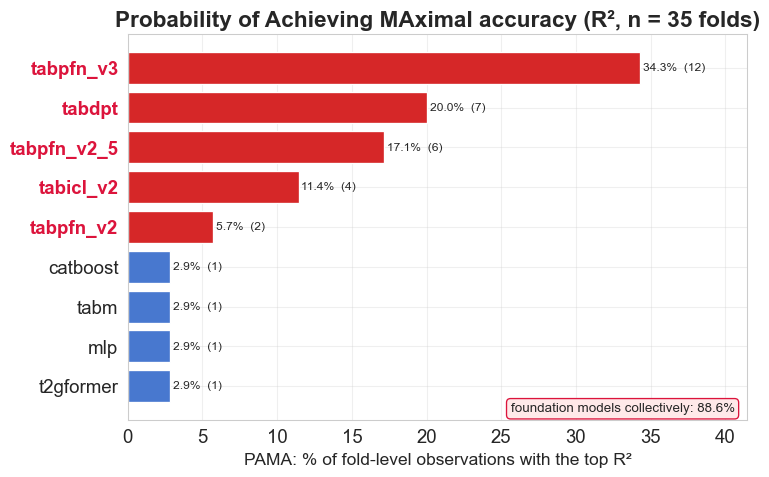

,wins,n_folds,PAMA_%
method,,,
tabpfn_v3,12,35,34.285714
tabdpt,7,35,20.000000
tabpfn_v2_5,6,35,17.142857
tabicl_v2,4,35,11.428571
tabpfn_v2,2,35,5.714286
catboost,1,35,2.857143
tabm,1,35,2.857143
mlp,1,35,2.857143
t2gformer,1,35,2.857143


In [3]:
st.plot_pama_bars(df_folds, 'R2', metric_name='R2', foundation_methods=FND,
                  out_path=FIGURES_DIR / 'lgd_pama.pdf')
display(st.pama_fold_level(df_folds, 'R2').head(12))

## 2. Do the methods differ at all? — Friedman omnibus test

**What it is.** The Friedman test ranks methods within each dataset and tests whether the *average ranks* depart from equality; the **Iman–Davenport** F-correction is less conservative. **How to read it.** A small p-value rejects "all methods are equal" and licenses the post-hoc comparisons that follow.

In [4]:
f = st.friedman_test(mat)
print(f"N={f['N']} datasets, k={f['k']} methods")
print(f"Friedman/Iman-Davenport: F_F = {f['iman_davenport_F']:.2f}, p = {f['p_iman_davenport']:.3g}")

N=7 datasets, k=27 methods
Friedman/Iman-Davenport: F_F = 8.49, p = 6.94e-19


## 3. More powerful omnibus alternatives — Aligned Ranks & Quade

**Why.** With many methods but few datasets, the plain Friedman test loses power. The **Friedman Aligned Ranks** and **Quade** tests (García et al., 2010) recover power. **How to read it.** Agreement with Friedman means the global signal is robust.

In [5]:
fa = st.friedman_aligned_ranks_test(mat); qu = st.quade_test(mat)
print(f"Aligned Ranks: chi2 = {fa['aligned_ranks_chi2']:.1f}, p = {fa['p']:.3g}")
print(f"Quade:         F   = {qu['quade_F']:.2f}, p = {qu['p']:.3g}")

Aligned Ranks: chi2 = 96.4, p = 5.02e-10
Quade:         F   = 5.10, p = 4.16e-11


## 4. Which methods are indistinguishable? — critical-difference diagram

**What it is.** Methods on the average-rank axis (rank 1 = best, left). Two methods whose ranks differ by less than the **critical difference (CD)** are not significantly different (Nemenyi, α = 0.05) and are joined by a bar. Foundation models in red.

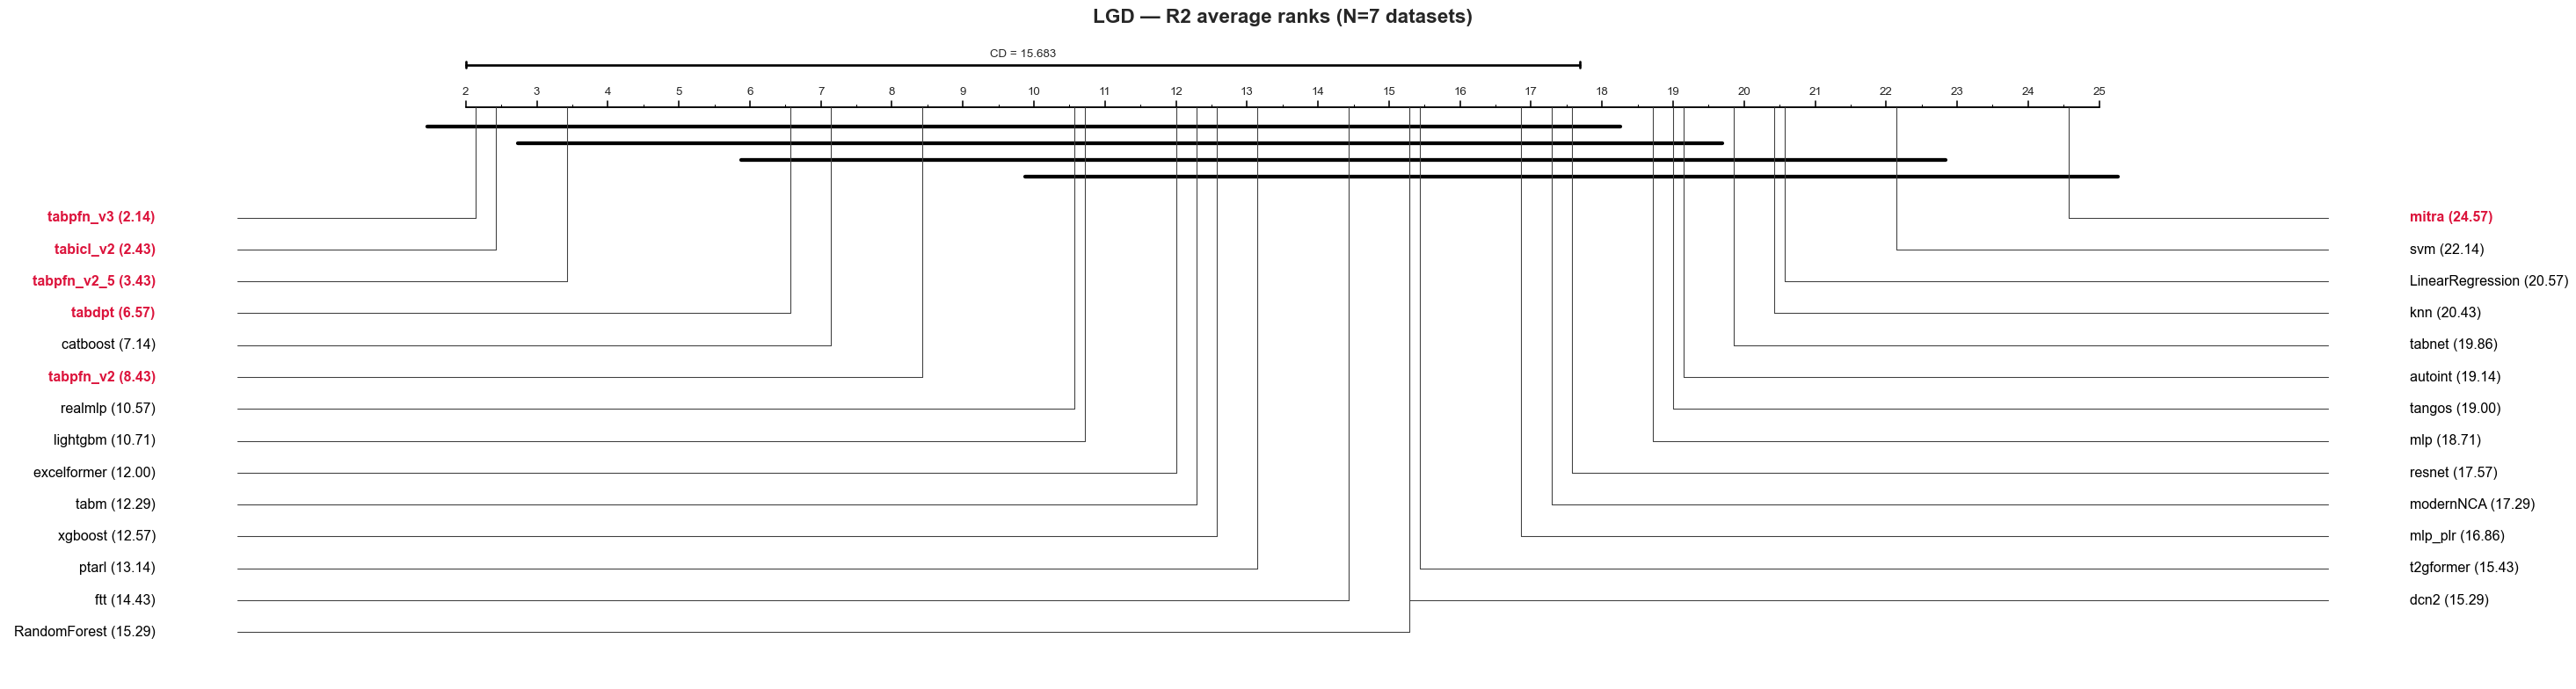

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/lgd_stats/lgd_cd_r2.pdf')

In [6]:
st.plot_cd_diagram(ranks, st.nemenyi_cd(mat.shape[1], mat.shape[0]),
                   title=f'LGD — R2 average ranks (N={mat.shape[0]} datasets)',
                   out_path=FIGURES_DIR / 'lgd_cd_r2.pdf')

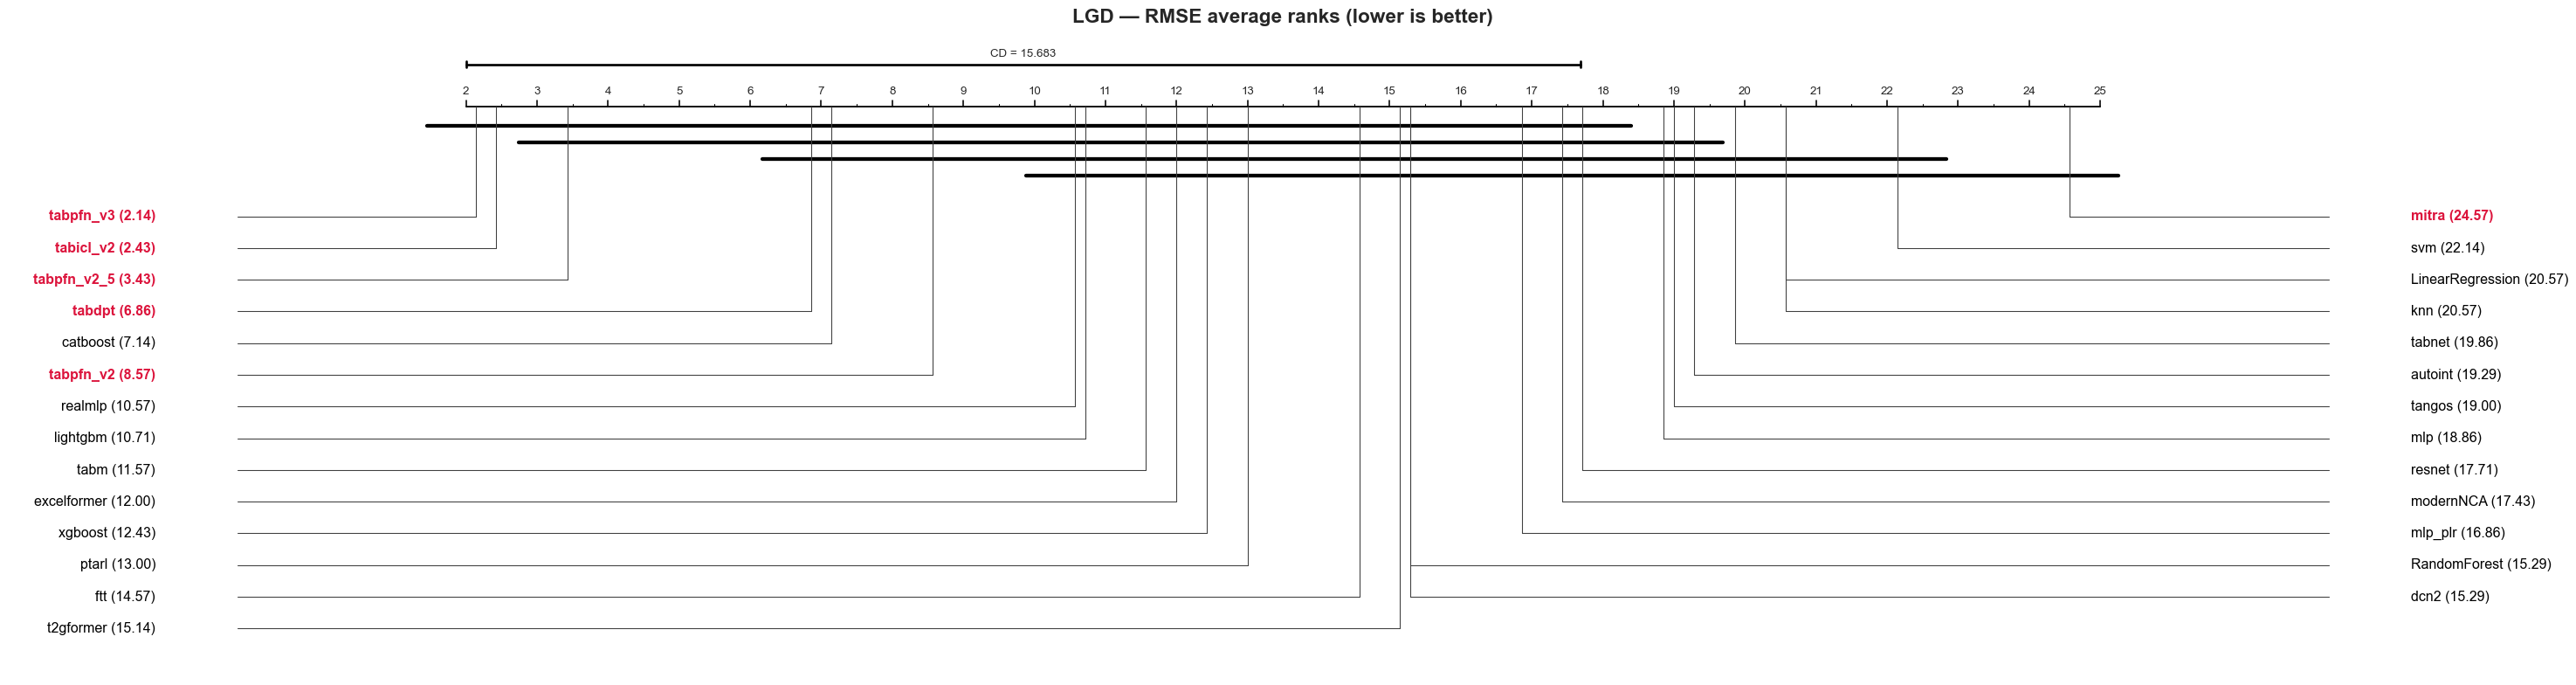

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/lgd_stats/lgd_cd_rmse.pdf')

In [7]:
mat2 = st.metric_matrix(df, 'RMSE')
st.plot_cd_diagram(st.average_ranks(mat2, higher_is_better=False),
                   st.nemenyi_cd(mat2.shape[1], mat2.shape[0]),
                   title='LGD — RMSE average ranks (lower is better)',
                   out_path=FIGURES_DIR / 'lgd_cd_rmse.pdf')

## 5. Every head-to-head — Win/Loss matrix

**What it is.** For each ordered pair, the number of datasets the row method beats the column method (cell = Win/Loss; colour = margin). Shows the *direction and consistency* of each duel regardless of significance. Ordered best-first.

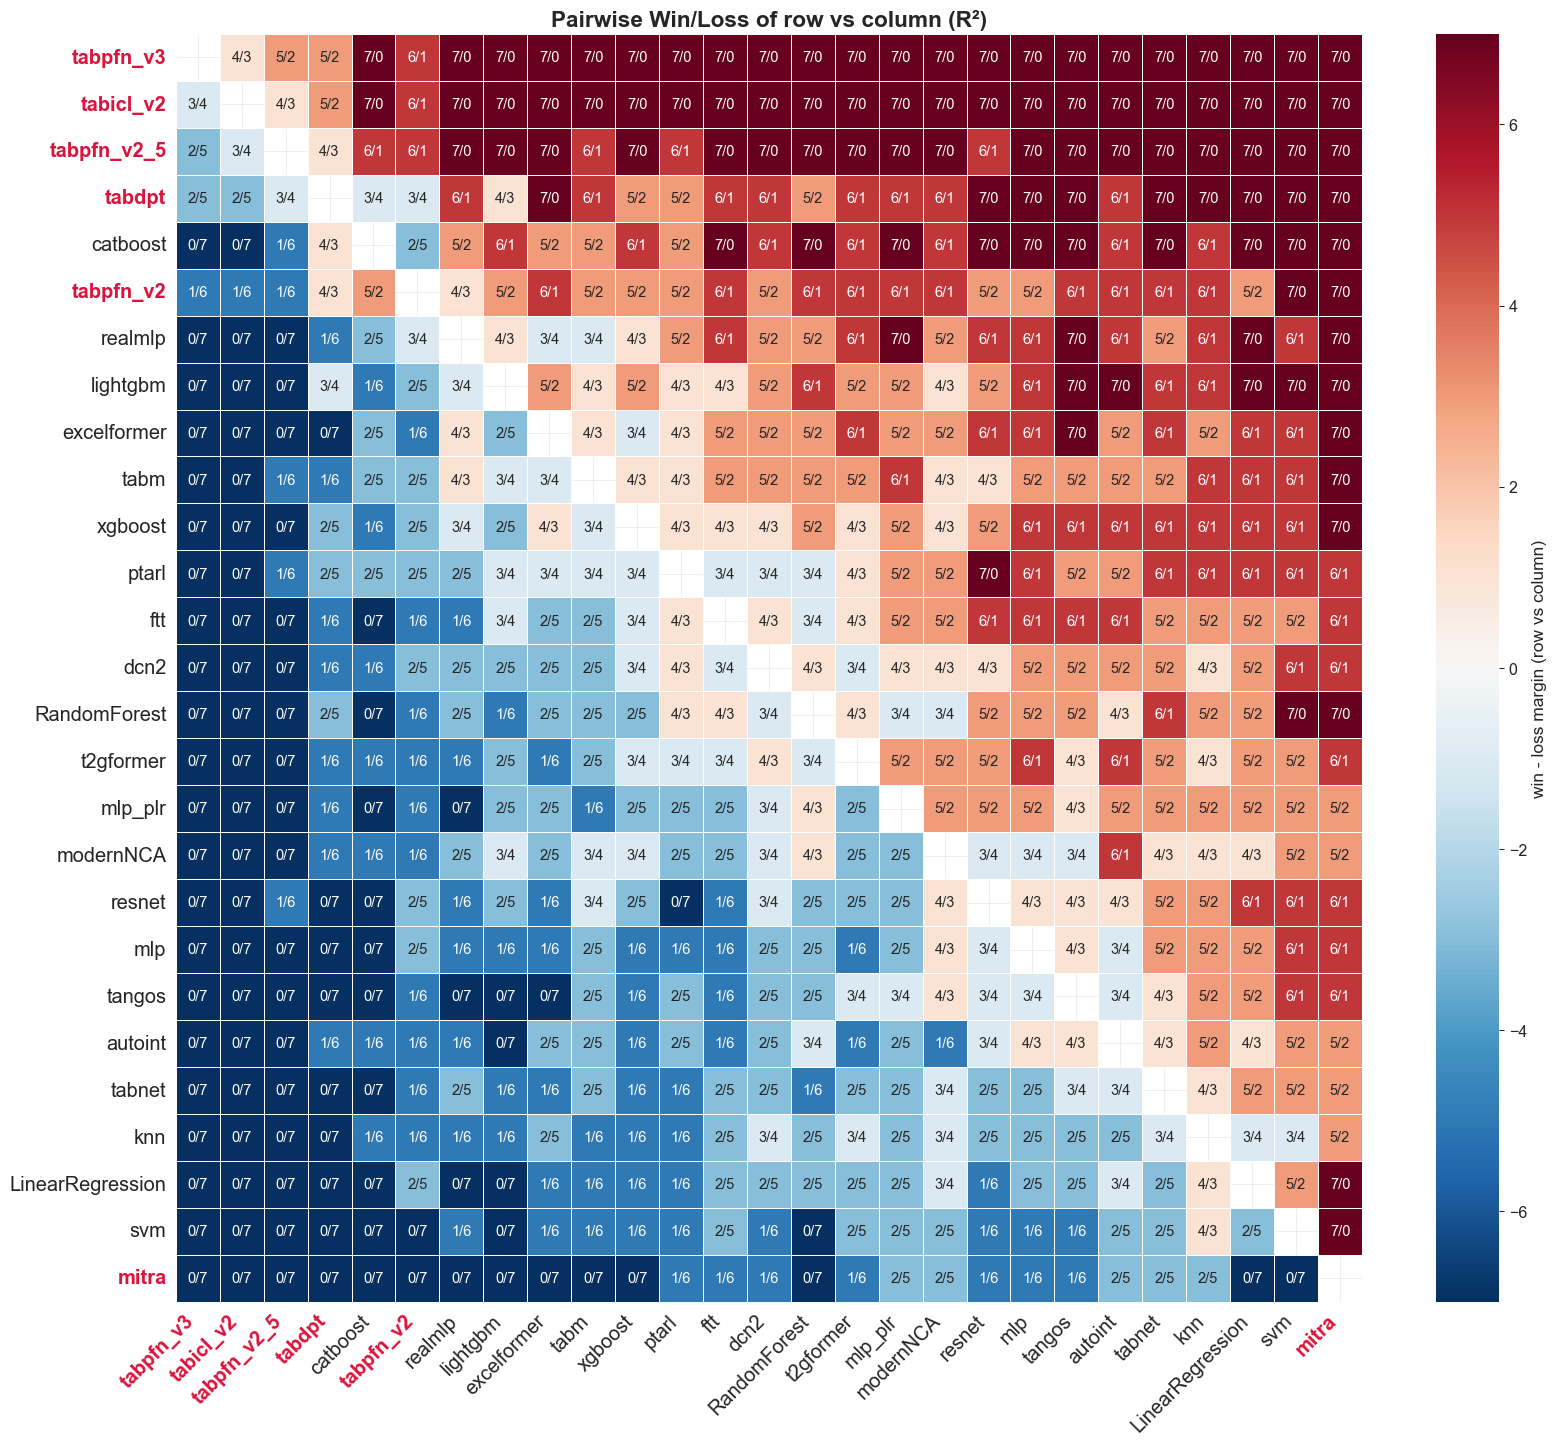

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/lgd_stats/lgd_winloss.pdf')

In [8]:
st.plot_wilcoxon_wl_matrix(mat, metric_name='R2',
                           out_path=FIGURES_DIR / 'lgd_winloss.pdf')

## 6. Which differences are significant? — Wilcoxon & t-test, both Holm-corrected

**What it is.** We test each pair and Holm-correct across all pairs to control the family-wise error. We report **two** complementary tests: the **Wilcoxon signed-rank** test (non-parametric; uses the sign and magnitude of per-dataset differences, no normality assumption — Demšar's recommendation) and the **paired Student's t-test** (parametric; assumes roughly normal differences — the procedure several recent tabular-ML benchmarks adopt, e.g. Ye et al. 2024; Liu et al. 2024). **How to read it.** Agreement between the two strengthens confidence; a short list after correction is expected with many methods and few datasets, and does not contradict a significant omnibus test.

In [9]:
st.significant_pairs_text(mat, test='wilcoxon', metric_name='R2')
N = mat.shape[0]
print(f'\nNote: with only N={N} datasets the smallest possible two-sided p is '
      f'{2/2**N:.3f}; after Holm over all pairs, individual significance is structurally '
      f'hard to reach here -- this does not contradict a significant omnibus test.')

Significant pairwise differences in R² (Wilcoxon signed-rank, Holm-corrected, alpha = 0.05):
  0 of 351 pairs significant.

  (none reach significance after Holm correction)

Note: with only N=7 datasets the smallest possible two-sided p is 0.016; after Holm over all pairs, individual significance is structurally hard to reach here -- this does not contradict a significant omnibus test.


In [10]:
st.significant_pairs_text(mat, test='ttest', metric_name='R2')

Significant pairwise differences in R² (paired t-test, Holm-corrected, alpha = 0.05):
  0 of 351 pairs significant.

  (none reach significance after Holm correction)


'Significant pairwise differences in R² (paired t-test, Holm-corrected, alpha = 0.05):\n  0 of 351 pairs significant.\n\n  (none reach significance after Holm correction)'

## 7. The same, as a colour map — adjusted-p-value matrix

**What it is.** For every pair, the **Shaffer-adjusted** p-value of the rank difference. Shaffer's static procedure exploits the logical dependencies among the hypotheses to be less conservative than Holm while still controlling the family-wise error (García & Herrera, 2008). **How to read it.** A **green** cell = that pair differs significantly (adjusted p < 0.05); red = not. Ordered best-first; foundation models in red.

[stat] Bergmann-Hommel skipped (k=27 > 8; exhaustive-set enumeration infeasible) -- use Shaffer instead.


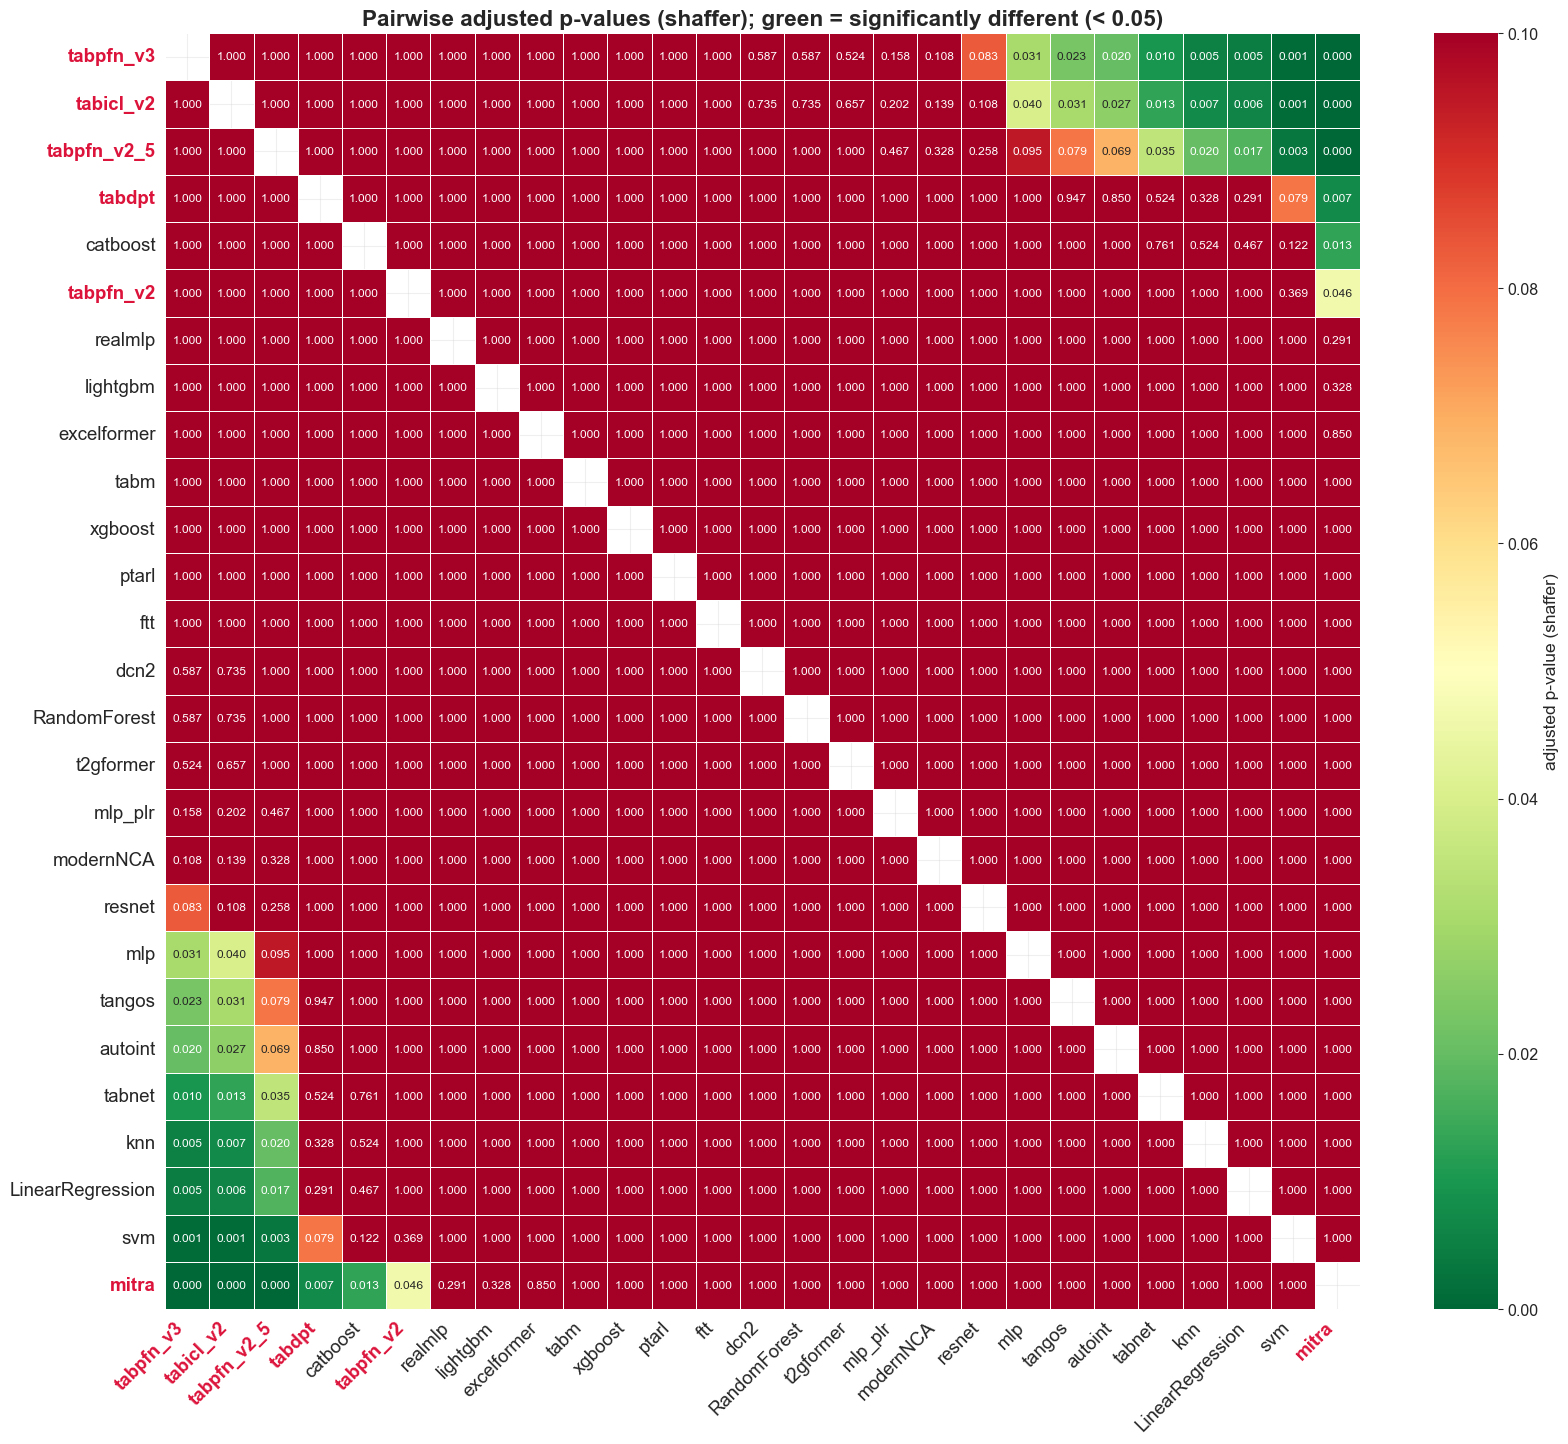

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/lgd_stats/lgd_significance.pdf')

In [11]:
apv = st.pairwise_apv_table(mat)
st.plot_significance_matrix(apv, mat.columns, order=list(ranks.index),
                            out_path=FIGURES_DIR / 'lgd_significance.pdf')

## 8. The practical question — Bayesian signed-rank test with a ROPE

**What it is.** The **Bayesian signed-rank test** (Benavoli et al., 2014; 2017) — the Bayesian analogue of the Wilcoxon test, and the procedure **Gunnarsson et al. (2021)** used for credit scoring. With a **region of practical equivalence (ROPE)** it returns the posterior probability that one method is *practically* better, that they are equivalent, or that the other is better — and it needs **no family-wise correction**, a real advantage when many methods are compared. We compare the two leading foundation models (**TabPFN v3** vs **TabICL v2**) head-to-head, and each against strong baselines (**CatBoost**, **LinearRegression**).

In [12]:
import itertools as _it
FOCUS = [m for m in ('tabpfn_v3', 'tabicl_v2', 'catboost', 'LinearRegression') if m in mat.columns]
for x, y in _it.combinations(FOCUS, 2):
    r = st.bayesian_signed_rank_test(mat[x], mat[y], rope=0.01)
    print(f'{x:12s} vs {y:12s}:  P({x} better)={r["P_right"]:.3f}  '
          f'P(equivalent)={r["P_rope"]:.3f}  P({y} better)={r["P_left"]:.3f}')

tabpfn_v3    vs tabicl_v2   :  P(tabpfn_v3 better)=0.406  P(equivalent)=0.562  P(tabicl_v2 better)=0.032
tabpfn_v3    vs catboost    :  P(tabpfn_v3 better)=0.925  P(equivalent)=0.075  P(catboost better)=0.000
tabpfn_v3    vs LinearRegression:  P(tabpfn_v3 better)=0.973  P(equivalent)=0.027  P(LinearRegression better)=0.000
tabicl_v2    vs catboost    :  P(tabicl_v2 better)=0.957  P(equivalent)=0.043  P(catboost better)=0.000
tabicl_v2    vs LinearRegression:  P(tabicl_v2 better)=0.988  P(equivalent)=0.012  P(LinearRegression better)=0.000
catboost     vs LinearRegression:  P(catboost better)=0.973  P(equivalent)=0.027  P(LinearRegression better)=0.000


> **The story in one line.** PAMA shows who wins most; the omnibus tests confirm the differences are real; the CD diagram and Win/Loss matrix show *who* and *by how much*; Wilcoxon/t-test + Holm isolate the rigorously-significant pairs; and the Bayesian ROPE analysis turns that into the practical probability of superiority.

## 9. Summary — copy-paste report

A single plain-text dump of every test above — PAMA, average ranks, Friedman/Iman-Davenport, Friedman-Aligned-Ranks & Quade, the Nemenyi critical difference, the Holm-corrected Wilcoxon **and** paired-t significant pairs, the García & Herrera all-pairwise adjusted p-values, and the Bayesian signed-rank verdicts — ready to paste into another tool for interpretation.

In [13]:
st.statistical_report(df, df_folds, metric='R2', task_name='LGD',
                      higher_is_better=True,
                      focus=['tabpfn_v3', 'tabicl_v2', 'catboost', 'LinearRegression'])

[stat] Bergmann-Hommel skipped (k=27 > 8; exhaustive-set enumeration infeasible) -- use Shaffer instead.
STATISTICAL SUMMARY — LGD R²  (7 datasets x 27 methods; higher is better; alpha = 0.05)

[1] PAMA — probability of achieving the maximal score (% of (dataset, fold) observations where the method is the single best):
      tabpfn_v3             34.3%   (12/35)
      tabdpt                20.0%   (7/35)
      tabpfn_v2_5           17.1%   (6/35)
      tabicl_v2             11.4%   (4/35)
      tabpfn_v2              5.7%   (2/35)
      catboost               2.9%   (1/35)
      tabm                   2.9%   (1/35)
      mlp                    2.9%   (1/35)
      t2gformer              2.9%   (1/35)
      LinearRegression       0.0%   (0/35)
      resnet                 0.0%   (0/35)
      tangos                 0.0%   (0/35)
      tabnet                 0.0%   (0/35)
      svm                    0.0%   (0/35)
      ptarl                  0.0%   (0/35)

[2] Average ranks across dataset

"==============================================================================\nSTATISTICAL SUMMARY — LGD R²  (7 datasets x 27 methods; higher is better; alpha = 0.05)\n==============================================================================\n\n[1] PAMA — probability of achieving the maximal score (% of (dataset, fold) observations where the method is the single best):\n      tabpfn_v3             34.3%   (12/35)\n      tabdpt                20.0%   (7/35)\n      tabpfn_v2_5           17.1%   (6/35)\n      tabicl_v2             11.4%   (4/35)\n      tabpfn_v2              5.7%   (2/35)\n      catboost               2.9%   (1/35)\n      tabm                   2.9%   (1/35)\n      mlp                    2.9%   (1/35)\n      t2gformer              2.9%   (1/35)\n      LinearRegression       0.0%   (0/35)\n      resnet                 0.0%   (0/35)\n      tangos                 0.0%   (0/35)\n      tabnet                 0.0%   (0/35)\n      svm                    0.0%   (0/35)\n   